In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import figure


In [2]:
df = pd.read_csv("/content/netflix_titles.csv", engine='python', on_bad_lines='skip')

In [3]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


### DATA EXPLORATION

In [4]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
print("Type of Content:")
print(df["type"].unique())

print("\nType of Rating:")
print(df["rating"].unique())

print("\nNumber of Movie and TV Show:")
print(df["type"].value_counts())

print("\nNumber of Rating")
print(df["rating"].value_counts())

print("\nNumber of Duplicate:")
print(df.duplicated().sum())

print("\nDuplicate Rowa")
print(df[df.duplicated()])

print("\nNumber of Duplicate Title:")
print(df['title'].duplicated().sum())

print("\nDuplicate Title")
print(df[df['title'].duplicated(keep=False)].sort_values('title'))

print("\nNumber of Country:")
print(df["country"].nunique())

Type of Content:
['Movie' 'TV Show']

Type of Rating:
['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' '74 min' '84 min' '66 min' 'NR' nan 'TV-Y7-FV' 'UR']

Number of Movie and TV Show:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Number of Rating
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

Number of Duplicate:
0

Duplicate Rowa
Empty DataFrame
Columns: [show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, description]
Index: []

Number of Duplicate Title:
0

Duplicate Title
Empty DataFrame
Columns: [show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, description]
Inde

In [7]:
df[df["rating"].isin(['74 min', '84 min', '66 min'])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [8]:
df["country"].dropna().sample(20)

,country
918,India
4300,United States
2749,United States
5525,United States
6381,United States
3995,Uruguay
4420,India
3642,United States
3063,South Korea
4725,India


In [9]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [10]:
print("Missing value percentage: ")
print((df.isnull().sum()/len(df))*100)

Missing value percentage: 
show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64


In [11]:
print("Date Sample:")
print(df["date_added"].sample(20))

Date Sample:
3030      January 13, 2020
294         August 7, 2021
5588     February 26, 2017
2331         June 26, 2020
7233     September 8, 2017
6378       October 2, 2019
6408      February 1, 2017
1726      November 6, 2020
4292     December 16, 2018
992         April 23, 2021
4757         July 24, 2018
3223     November 27, 2019
5       September 24, 2021
1261     February 26, 2021
4575       October 1, 2018
5883     November 18, 2015
727          June 13, 2021
5131      December 8, 2017
3242     November 22, 2019
3897        April 19, 2019
Name: date_added, dtype: object


In [12]:
print("Duration Sample:")
print(df["duration"].sample(20))

Duration Sample:
2849      61 min
5746      97 min
6287      98 min
1499     119 min
1417      81 min
4701     105 min
8538      58 min
1727      82 min
2925     102 min
8088      89 min
824       97 min
7651      89 min
546     1 Season
3996    1 Season
7986     146 min
3405     100 min
2635     124 min
7492      74 min
1550     107 min
5129      89 min
Name: duration, dtype: object


In [13]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [14]:
df['date_added'] = df['date_added'].astype('datetime64[ns]')
df['date_added'] = df['date_added'].dt.strftime('%Y-%m-%d')

In [15]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [16]:
df['date_added'] = pd.to_datetime(df['date_added'])

In [17]:
df['date_added'].dtype

dtype('<M8[ns]')

In [18]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,datetime64[ns]
release_year,int64
rating,object
duration,object


In [19]:
print("Converted Date Sample:")
print(df['date_added'].sample(20))

Converted Date Sample:
435    2021-07-20
851    2021-05-21
3604   2019-08-09
6634   2020-11-01
3341   2019-11-01
3323   2019-11-02
3542   2019-09-01
6616   2018-02-19
2760   2020-03-29
5758   2016-10-07
1820   2020-10-19
3876   2019-04-30
1722   2020-11-10
1172   2021-03-23
7788   2016-01-01
30     2021-09-17
4014   2019-03-15
5534   2017-04-12
2200   2020-07-29
1099   2021-04-04
Name: date_added, dtype: datetime64[ns]


In [20]:

df['added year'] = df['date_added'].dt.year
df['added month'] = df['date_added'].dt.month
df['added day'] = df['date_added'].dt.day

In [21]:
print("Day, Month, Year: ")
print(df[['added day','added month', 'added year']].head())

Day, Month, Year: 
   added day  added month  added year
0       25.0          9.0      2021.0
1       24.0          9.0      2021.0
2       24.0          9.0      2021.0
3       24.0          9.0      2021.0
4       24.0          9.0      2021.0


In [22]:
df['added year'] = df['added year'].astype('Int64')
df['added month'] = df['added month'].astype('Int64')
df['added day'] = df['added day'].astype('Int64')

In [23]:
print("Day, Month, Year: ")
print(df[['added day','added month', 'added year']].head())

Day, Month, Year: 
   added day  added month  added year
0         25            9        2021
1         24            9        2021
2         24            9        2021
3         24            9        2021
4         24            9        2021


In [24]:
df['duration']

,duration
0,90 min
1,2 Seasons
2,1 Season
3,1 Season
4,2 Seasons
...,...
8802,158 min
8803,2 Seasons
8804,88 min
8805,88 min


In [25]:
df['duration_value'] = df['duration'].str.extract('(\d+)')

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_987/1441165468.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['duration_value'] = df['duration'].str.extract('(\d+)')


In [26]:
df['duration_value'] = pd.to_numeric(df['duration_value'])


In [27]:
df['duration_value']

,duration_value
0,90.0
1,2.0
2,1.0
3,1.0
4,2.0
...,...
8802,158.0
8803,2.0
8804,88.0
8805,88.0


In [28]:
df['duration_value'].dtype

dtype('float64')

In [29]:
df['duration_value'].isnull().sum()

np.int64(3)

In [30]:
df['duration_value'] = df['duration_value'].astype('Int64')

In [31]:
df['duration_value'].dtype

Int64Dtype()

In [32]:
df['duration_type'] = df['duration'].str.extract('([a-zA-Z]+)')

In [33]:
print("Duration Types:")
print(df['duration_type'].sample(20))

Duration Types:
773         min
3861    Seasons
5434     Season
7459     Season
6843        min
5244    Seasons
4395        min
90          min
2000        min
8038        min
4343        min
1446        min
8070    Seasons
2435        min
6221        min
5735        min
1562     Season
254     Seasons
1131        min
3460        min
Name: duration_type, dtype: object


In [34]:
print("Duration value sample")
print(df['duration_value'].sample(20))

Duration value sample
4292    112
1897    115
4717      3
4086     89
7441     86
7299     83
4603    127
7152     94
7604     54
1106    100
3531    142
8315      2
1913     75
3918    101
4811     90
6002    101
5180      6
7866     84
4532     89
4723    163
Name: duration_value, dtype: Int64


In [35]:
print("Types of column")
print(df.dtypes)

Types of column
show_id                   object
type                      object
title                     object
director                  object
cast                      object
country                   object
date_added        datetime64[ns]
release_year               int64
rating                    object
duration                  object
listed_in                 object
description               object
added year                 Int64
added month                Int64
added day                  Int64
duration_value             Int64
duration_type             object
dtype: object


### EDA OF NETFLIX DATA

In [36]:
print("\nNumber of Movie and TV Show:")
print(df["type"].value_counts())


Number of Movie and TV Show:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [37]:
print("Percentage of Movie and TV shows:")
print(round((df["type"].value_counts("")/df["type"].count())*100,2))

Percentage of Movie and TV shows:
type
Movie      69.62
TV Show    30.38
Name: count, dtype: float64


In [38]:
total_content = df['type'].value_counts()
total_content

,count
type,
Movie,6131
TV Show,2676


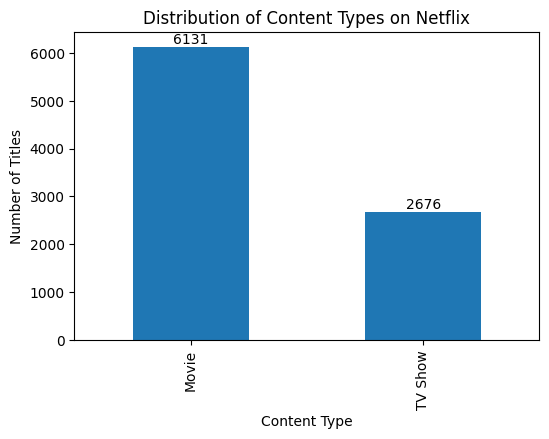

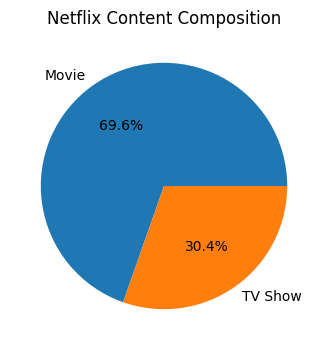

In [39]:
#BAR CHART
ax = total_content.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Distribution of Content Types on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

for container in ax.containers:
    ax.bar_label(container)

plt.show()


#PIE CHART
plt.figure(figsize=(6,4))
plt.pie(
    total_content,
    labels=total_content.index,
    autopct='%1.1f%%'
)
plt.title('Netflix Content Composition')

plt.show()

In [40]:
df['country'].value_counts().head(20)

,count
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


In [41]:
no_of_multicountrty_row = df['country'].str.contains(',',na=False).sum()
no_of_multicountrty_row

np.int64(1320)

In [42]:
total_rows = df['country'].count()
total_rows

np.int64(7976)

In [43]:
percentage_of_rows_with_multiple_countries = (no_of_multicountrty_row/total_rows)*100
percentage_of_rows_with_multiple_countries

np.float64(16.549648946840524)

In [44]:
print("Top 10 Country contribution")
print(df['country'].value_counts().head(10))

Top 10 Country contribution
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


In [45]:
top_10_countries = df['country'].value_counts().head(10)

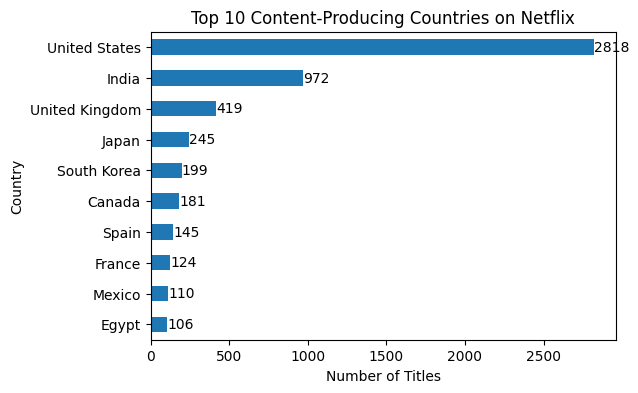

In [46]:
ax = top_10_countries.sort_values().plot(
    kind='barh',
    figsize=(6,4)
)
plt.title('Top 10 Content-Producing Countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

The United States is the largest contributor to Netflix's catalog with 2,818 titles, contributing nearly three times more content than India, the second-largest contributor.

Netflix's content is distributed globally, makes it diverse.



SPLITING THE COUNTRIES


In [47]:
df['country']

,country
0,United States
1,South Africa
2,NaN
3,NaN
4,India
...,...
8802,United States
8803,NaN
8804,United States
8805,United States


In [48]:
df['country'].value_counts()

,count
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
...,...
"Mexico, United States, Spain, Colombia",1
"Canada, Norway",1
"Finland, Germany, Belgium",1


In [49]:
country_split = df['country'].dropna().str.split(',')
country_split

,country
0,[United States]
1,[South Africa]
4,[India]
7,"[United States, Ghana, Burkina Faso, United..."
8,[United Kingdom]
...,...
8801,"[United Arab Emirates, Jordan]"
8802,[United States]
8804,[United States]
8805,[United States]


In [50]:
country_exploded = country_split.explode()

In [51]:
country_exploded

,country
0,United States
1,South Africa
4,India
7,United States
7,Ghana
...,...
8801,Jordan
8802,United States
8804,United States
8805,United States


In [52]:
country_exploded = country_exploded.str.strip()

In [53]:
country_exploded

,country
0,United States
1,South Africa
4,India
7,United States
7,Ghana
...,...
8801,Jordan
8802,United States
8804,United States
8805,United States


In [54]:
country_counts = country_exploded.value_counts()

In [55]:
country_counts.head(10)

,count
country,
United States,3690
India,1046
United Kingdom,806
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


In [56]:
df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


In [57]:
country_df = country_counts.reset_index()
country_df.columns = ['Country', 'Count']

country_df.head()

,Country,Count
0,United States,3690
1,India,1046
2,United Kingdom,806
3,Canada,445
4,France,393


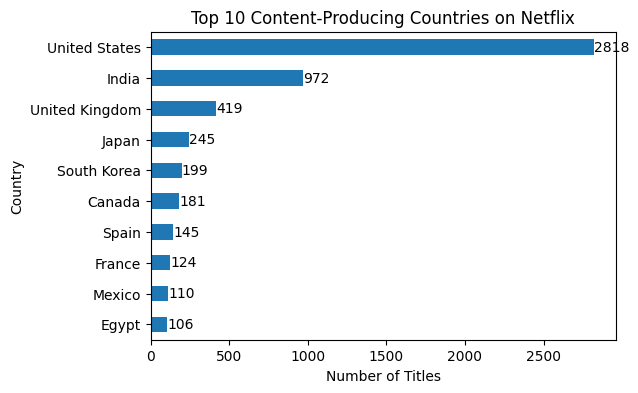

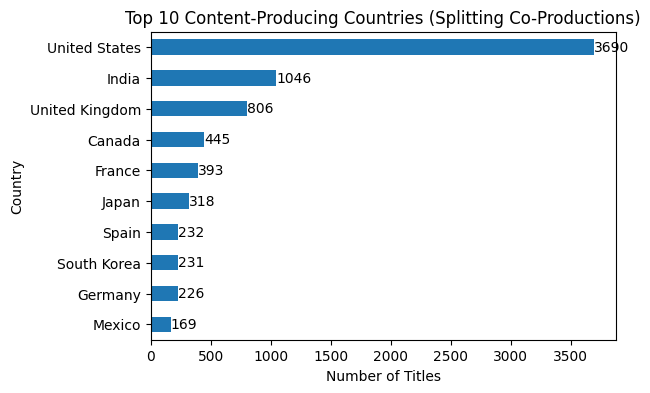

In [58]:
ax = top_10_countries.sort_values().plot(
    kind='barh',
    figsize=(6,4)
)
plt.title('Top 10 Content-Producing Countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

#Splited Plot for Country
top_10 = country_df.head(10)

ax = top_10.sort_values('Count').plot(
    x='Country',
    y='Count',
    kind='barh',
    figsize=(6,4),
    legend=False
)

plt.title('Top 10 Content-Producing Countries (Splitting Co-Productions)')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Updated Insight of Country's Contribution

*   USA's contribution increased significantly and also the conent of India, UK, Canada has increased after spliting the co-productions.
*   Germany was not in the Top 10 list but it was contributing through co-prodcutions
*   Earlier USA was about 2.9 times more than India, but add the co-productions it's now more than 3 times of India's contribution.



### Trend Analysis by Year

In [59]:
df['release_year'].describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [60]:
df['release_year'].value_counts().sort_index().tail(20)

,count
release_year,
2002,51
2003,61
2004,64
2005,80
2006,96
2007,88
2008,136
2009,152
2010,194


In [61]:
len(df)

8807

In [62]:
df['release_year'].value_counts().sum()

np.int64(8807)

In [63]:
yearly_content = df['release_year'].value_counts().sort_index()
yearly_content

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1032
2018,1147
2019,1030


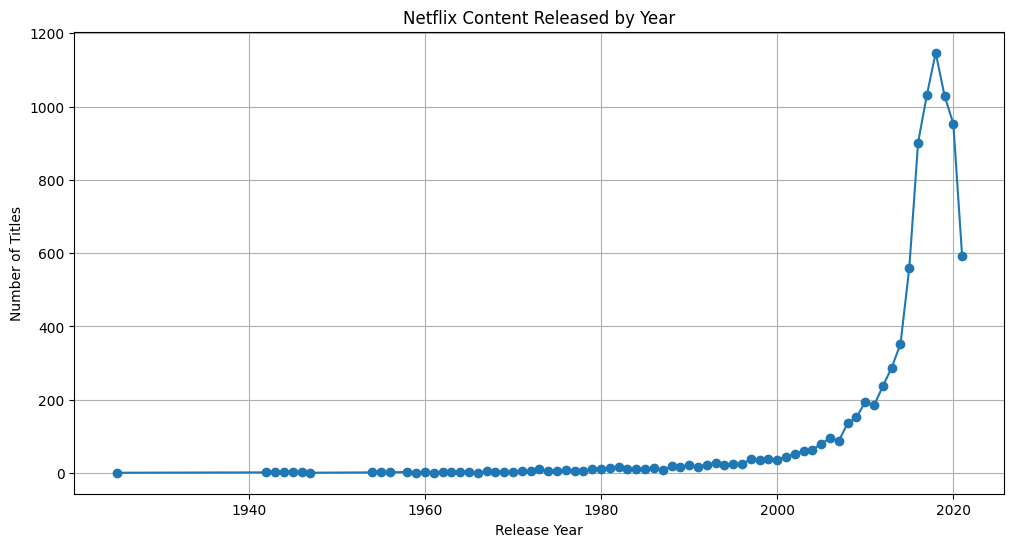

In [64]:
plt.figure(figsize=(12,6))

plt.plot(
    yearly_content.index,
    yearly_content.values,
    marker='o'
)

plt.title('Netflix Content Released by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.grid(True)

plt.show()

In [65]:
yearly_content.idxmax()

np.int64(2018)

In [66]:
yearly_content.max()

1147

In [67]:
df['listed_in'].head(10)

,listed_in
0,Documentaries
1,"International TV Shows, TV Dramas, TV Mysteries"
2,"Crime TV Shows, International TV Shows, TV Act..."
3,"Docuseries, Reality TV"
4,"International TV Shows, Romantic TV Shows, TV ..."
5,"TV Dramas, TV Horror, TV Mysteries"
6,Children & Family Movies
7,"Dramas, Independent Movies, International Movies"
8,"British TV Shows, Reality TV"
9,"Comedies, Dramas"


In [68]:
df['listed_in'].sample(10)

,listed_in
1960,Documentaries
8139,"Dramas, Independent Movies, Thrillers"
3609,"International TV Shows, Korean TV Shows, Roman..."
1908,"Anime Series, International TV Shows, Teen TV ..."
4702,"Docuseries, International TV Shows, Science & ..."
6286,"Dramas, International Movies, Romantic Movies"
5392,"Kids' TV, TV Comedies"
5373,"Dramas, International Movies"
7455,Kids' TV
5300,"Action & Adventure, International Movies"


In [69]:
df['listed_in'].value_counts()

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
...,...
"Action & Adventure, Cult Movies",1
"Action & Adventure, Comedies, Music & Musicals",1
"Classic Movies, Horror Movies, Thrillers",1


In [70]:
genre_split = df['listed_in'].str.split(',')
genre_split

,listed_in
0,[Documentaries]
1,"[International TV Shows, TV Dramas, TV Myste..."
2,"[Crime TV Shows, International TV Shows, TV ..."
3,"[Docuseries, Reality TV]"
4,"[International TV Shows, Romantic TV Shows, ..."
...,...
8802,"[Cult Movies, Dramas, Thrillers]"
8803,"[Kids' TV, Korean TV Shows, TV Comedies]"
8804,"[Comedies, Horror Movies]"
8805,"[Children & Family Movies, Comedies]"


In [71]:
genre_explode = genre_split.explode()
genre_explode

,listed_in
0,Documentaries
1,International TV Shows
1,TV Dramas
1,TV Mysteries
2,Crime TV Shows
...,...
8805,Children & Family Movies
8805,Comedies
8806,Dramas
8806,International Movies


In [72]:
genre_explode = genre_explode.str.strip()
genre_explode

,listed_in
0,Documentaries
1,International TV Shows
1,TV Dramas
1,TV Mysteries
2,Crime TV Shows
...,...
8805,Children & Family Movies
8805,Comedies
8806,Dramas
8806,International Movies


In [73]:
genre_counts = genre_explode.value_counts()
genre_counts

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


In [74]:
genre_counts.head(20)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


In [75]:
genre_df = genre_counts.reset_index()
genre_df.columns = ['Genre', 'Count']

genre_df.head()

,Genre,Count
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1351
4,Documentaries,869


In [76]:
top_10_genre = genre_df.head(10)
top_10_genre

,Genre,Count
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1351
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,763
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


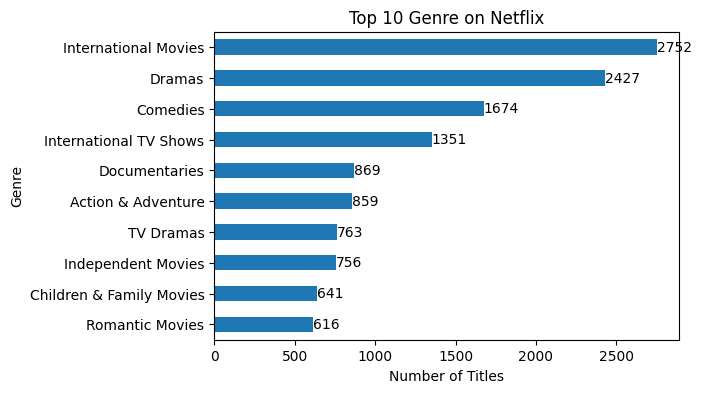

In [77]:

ax = top_10_genre.sort_values('Count').plot(
    x='Genre',
    y='Count',
    kind='barh',
    figsize=(6,4),
    legend=False
)
plt.title('Top 10 Genre on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

for contrainers in ax.containers:
    ax.bar_label(contrainers)
    plt.show()

In [78]:
df['type']

,type
0,Movie
1,TV Show
2,TV Show
3,TV Show
4,TV Show
...,...
8802,Movie
8803,TV Show
8804,Movie
8805,Movie


### Duration Analysis

In [79]:
movies = df[df['type'] == 'Movie']
tv_shows = df[df['type'] == 'TV Show']

In [80]:
movies['duration_value'].describe()

,duration_value
count,6128.0
mean,99.577187
std,28.290593
min,3.0
25%,87.0
50%,98.0
75%,114.0
max,312.0


In [81]:
tv_shows['duration_value'].describe()

,duration_value
count,2676.0
mean,1.764948
std,1.582752
min,1.0
25%,1.0
50%,1.0
75%,2.0
max,17.0


In [82]:
movie_duration = movies['duration_value']
tv_show_duration = tv_shows['duration_value']

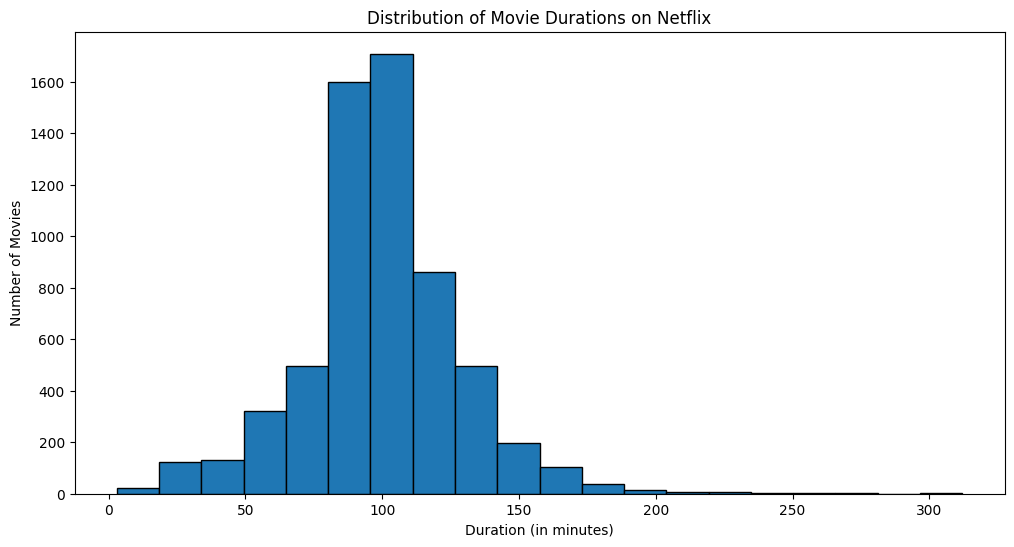

In [84]:
plt.figure(figsize=(12,6))
plt.hist(movie_duration,
         bins=20,
         edgecolor='black')

plt.title('Distribution of Movie Durations on Netflix')
plt.xlabel('Duration (in minutes)')
plt.ylabel('Number of Movies')

plt.show()

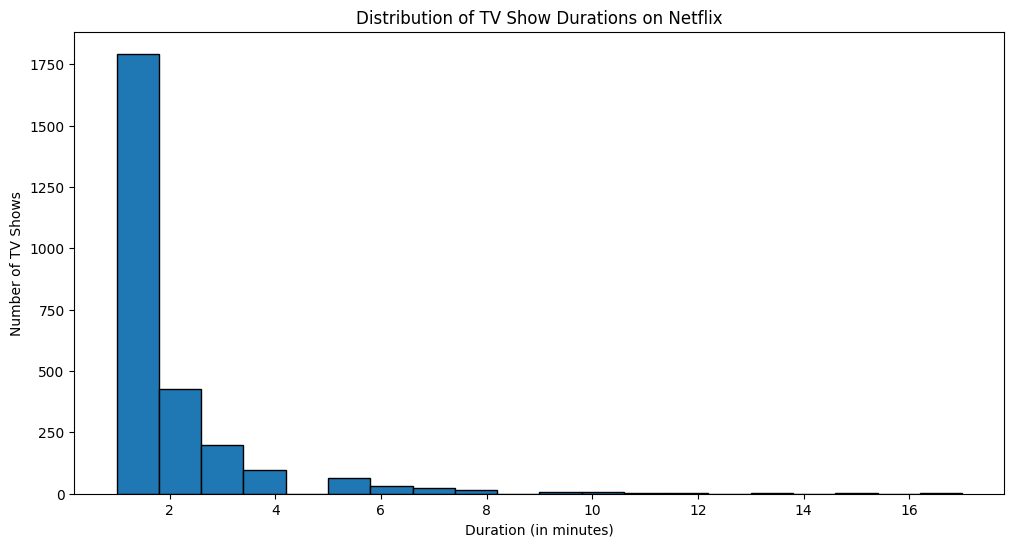

In [85]:
plt.figure(figsize=(12,6))
plt.hist(tv_show_duration,
         bins=20,
         edgecolor='black')
plt.title('Distribution of TV Show Durations on Netflix')
plt.xlabel('Duration (in minutes)')
plt.ylabel('Number of TV Shows')

plt.show()